# Precision vs Recall vs F1-Score
### Tiny Example for Crystal Clear Understanding

**Three metrics from confusion matrix:**
- Precision: Of predicted positives, how many are correct?
- Recall: Of actual positives, how many did we find?
- F1-Score: Harmonic mean of both (balance)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)

## 1. Tiny Example: 10 Patients
**Disease detection model**

In [2]:
# 10 patients - simple example
patients = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10']
y_true = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0])  # 4 sick, 6 healthy
y_pred = np.array([1, 1, 0, 0, 1, 0, 0, 0, 0, 0])  # Predicted sick

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# Calculate metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("10 Patients Example:")
print("="*60)
for i, (patient, true_label, pred_label) in enumerate(zip(patients, y_true, y_pred)):
    true_status = "SICK" if true_label == 1 else "Healthy"
    pred_status = "SICK" if pred_label == 1 else "Healthy"
    
    if true_label == pred_label:
        result = "✓ Correct"
    else:
        if pred_label == 1:
            result = "✗ False Positive"
        else:
            result = "✗ False Negative"
    
    print(f"{patient}: Actually {true_status:7s} | Predicted {pred_status:7s} | {result}")

print("\n" + "="*60)
print("Confusion Matrix:")
print(f"  TP (True Positive):  {tp} - Sick correctly identified")
print(f"  FP (False Positive): {fp} - Healthy wrongly called sick")
print(f"  FN (False Negative): {fn} - Sick wrongly called healthy")
print(f"  TN (True Negative):  {tn} - Healthy correctly identified")
print("="*60)

10 Patients Example:
P1: Actually SICK    | Predicted SICK    | ✓ Correct
P2: Actually SICK    | Predicted SICK    | ✓ Correct
P3: Actually SICK    | Predicted Healthy | ✗ False Negative
P4: Actually SICK    | Predicted Healthy | ✗ False Negative
P5: Actually Healthy | Predicted SICK    | ✗ False Positive
P6: Actually Healthy | Predicted Healthy | ✓ Correct
P7: Actually Healthy | Predicted Healthy | ✓ Correct
P8: Actually Healthy | Predicted Healthy | ✓ Correct
P9: Actually Healthy | Predicted Healthy | ✓ Correct
P10: Actually Healthy | Predicted Healthy | ✓ Correct

Confusion Matrix:
  TP (True Positive):  2 - Sick correctly identified
  FP (False Positive): 1 - Healthy wrongly called sick
  FN (False Negative): 2 - Sick wrongly called healthy
  TN (True Negative):  5 - Healthy correctly identified


## 2. Visual Breakdown

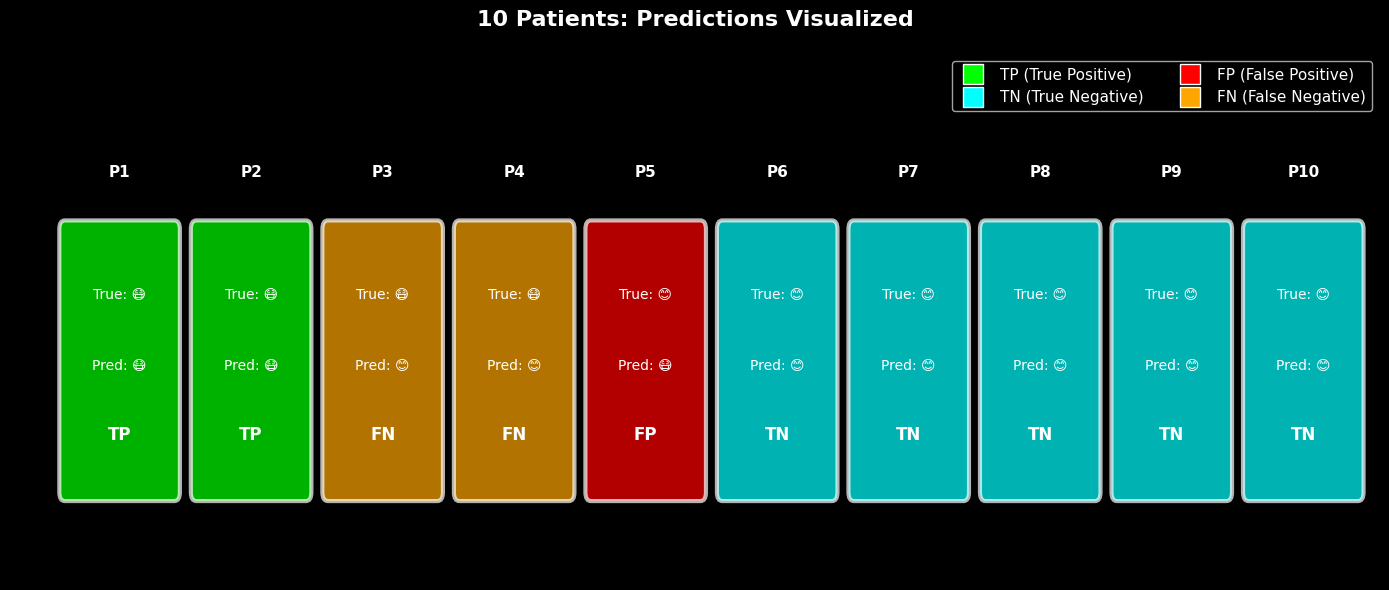

In [3]:
# Visualize predictions
fig, ax = plt.subplots(figsize=(14, 6))

y_pos = 0
for i, (patient, true_label, pred_label) in enumerate(zip(patients, y_true, y_pred)):
    x_pos = i * 1.2
    
    # Determine color based on outcome
    if true_label == 1 and pred_label == 1:
        color = 'lime'  # TP
        label_text = 'TP'
    elif true_label == 0 and pred_label == 0:
        color = 'cyan'  # TN
        label_text = 'TN'
    elif true_label == 0 and pred_label == 1:
        color = 'red'  # FP
        label_text = 'FP'
    else:
        color = 'orange'  # FN
        label_text = 'FN'
    
    # Draw rectangle
    rect = FancyBboxPatch((x_pos, 0), 1, 1.5, 
                          boxstyle="round,pad=0.05",
                          facecolor=color, edgecolor='white', 
                          linewidth=3, alpha=0.7)
    ax.add_patch(rect)
    
    # Patient name
    ax.text(x_pos + 0.5, 1.8, patient, ha='center', fontsize=11, 
           fontweight='bold', color='white')
    
    # True label
    true_text = '😷' if true_label == 1 else '😊'
    ax.text(x_pos + 0.5, 1.1, f'True: {true_text}', ha='center', 
           fontsize=10, color='white')
    
    # Predicted label
    pred_text = '😷' if pred_label == 1 else '😊'
    ax.text(x_pos + 0.5, 0.7, f'Pred: {pred_text}', ha='center', 
           fontsize=10, color='white')
    
    # Label type
    ax.text(x_pos + 0.5, 0.3, label_text, ha='center', fontsize=12, 
           fontweight='bold', color='white')

ax.set_xlim(-0.5, 12)
ax.set_ylim(-0.5, 2.5)
ax.axis('off')
ax.set_title('10 Patients: Predictions Visualized', 
            fontsize=16, fontweight='bold', pad=20)

# Legend
legend_elements = [
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='lime', 
              markersize=15, label='TP (True Positive)', linewidth=0),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='cyan', 
              markersize=15, label='TN (True Negative)', linewidth=0),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='red', 
              markersize=15, label='FP (False Positive)', linewidth=0),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', 
              markersize=15, label='FN (False Negative)', linewidth=0)
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

## 3. Precision Explained
**Of predicted sick, how many are actually sick?**

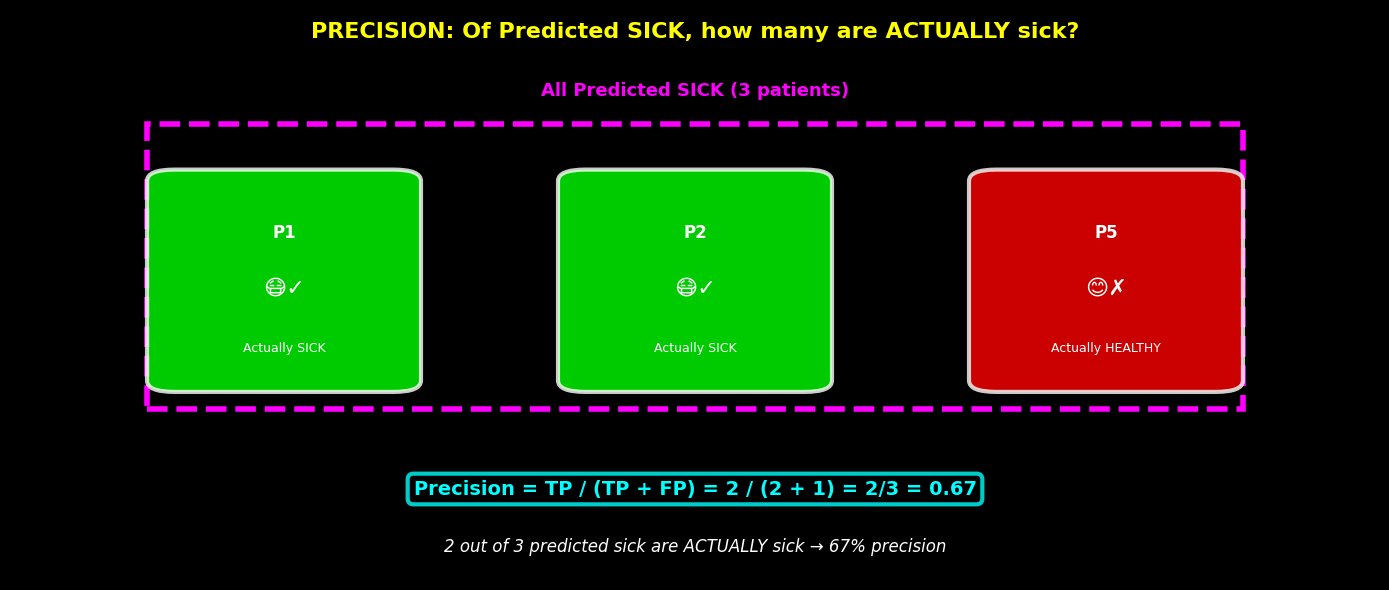


PRECISION = 66.67%
Interpretation: When model says SICK, it's correct 67% of the time


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

# Show only predicted positives
predicted_positive_indices = np.where(y_pred == 1)[0]

ax.text(0.5, 0.95, 'PRECISION: Of Predicted SICK, how many are ACTUALLY sick?', 
       transform=ax.transAxes, fontsize=16, fontweight='bold', 
       ha='center', color='yellow')

# Box for predicted positives
rect = Rectangle((0.1, 0.3), 0.8, 0.5, facecolor='none', 
                edgecolor='magenta', linewidth=4, linestyle='--')
ax.add_patch(rect)
ax.text(0.5, 0.85, 'All Predicted SICK (3 patients)', 
       transform=ax.transAxes, fontsize=13, ha='center', 
       color='magenta', fontweight='bold')

# Show patients
x_positions = [0.2, 0.5, 0.8]
for i, idx in enumerate(predicted_positive_indices):
    patient = patients[idx]
    true_label = y_true[idx]
    
    if true_label == 1:
        color = 'lime'
        icon = '😷✓'
        label = 'Actually SICK'
    else:
        color = 'red'
        icon = '😊✗'
        label = 'Actually HEALTHY'
    
    rect = FancyBboxPatch((x_positions[i]-0.08, 0.35), 0.16, 0.35, 
                          boxstyle="round,pad=0.02",
                          facecolor=color, edgecolor='white', 
                          linewidth=3, alpha=0.8, transform=ax.transAxes)
    ax.add_patch(rect)
    
    ax.text(x_positions[i], 0.6, patient, transform=ax.transAxes,
           ha='center', fontsize=12, fontweight='bold', color='white')
    ax.text(x_positions[i], 0.5, icon, transform=ax.transAxes,
           ha='center', fontsize=16)
    ax.text(x_positions[i], 0.4, label, transform=ax.transAxes,
           ha='center', fontsize=9, color='white')

# Formula
formula_text = f"Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {tp}/3 = {precision:.2f}"
ax.text(0.5, 0.15, formula_text, transform=ax.transAxes,
       fontsize=14, fontweight='bold', ha='center', color='cyan',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                edgecolor='cyan', linewidth=3))

ax.text(0.5, 0.05, '2 out of 3 predicted sick are ACTUALLY sick → 67% precision', 
       transform=ax.transAxes, fontsize=12, ha='center', 
       color='white', style='italic')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nPRECISION = {precision:.2%}")
print("Interpretation: When model says SICK, it's correct 67% of the time")

## 4. Recall Explained
**Of actually sick, how many did we find?**

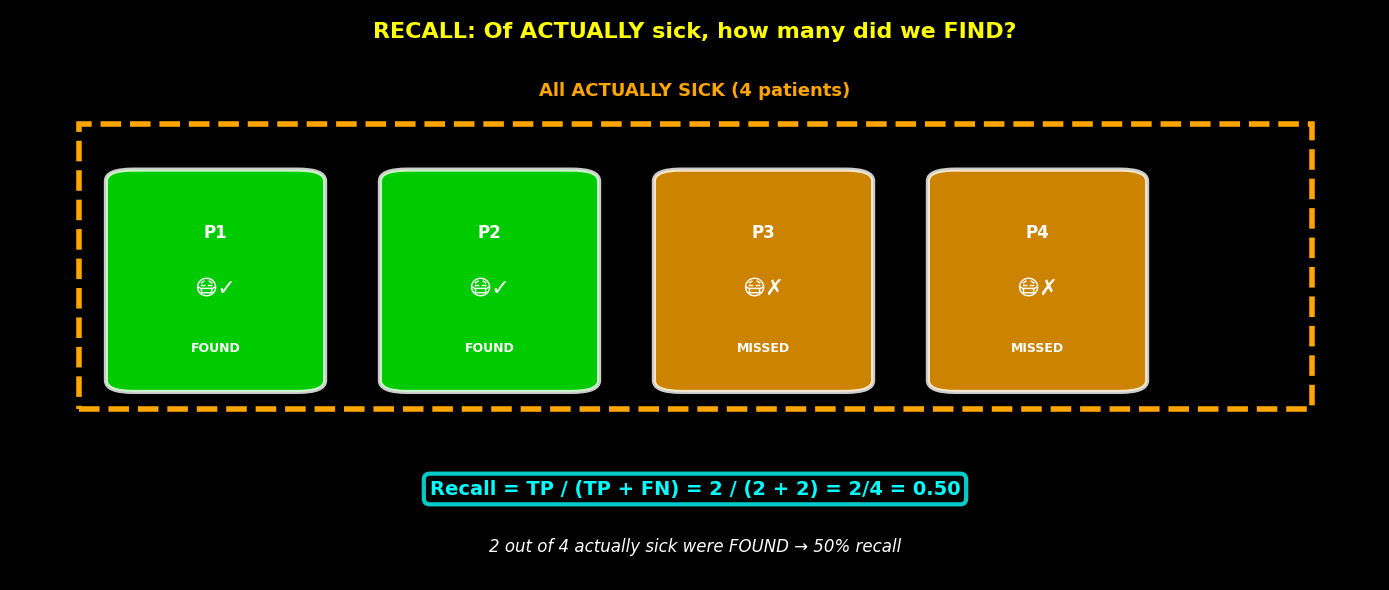


RECALL = 50.00%
Interpretation: We found only 50% of sick patients (MISSED 2!)


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# Show only actual positives
actual_positive_indices = np.where(y_true == 1)[0]

ax.text(0.5, 0.95, 'RECALL: Of ACTUALLY sick, how many did we FIND?', 
       transform=ax.transAxes, fontsize=16, fontweight='bold', 
       ha='center', color='yellow')

# Box for actual positives
rect = Rectangle((0.05, 0.3), 0.9, 0.5, facecolor='none', 
                edgecolor='orange', linewidth=4, linestyle='--')
ax.add_patch(rect)
ax.text(0.5, 0.85, 'All ACTUALLY SICK (4 patients)', 
       transform=ax.transAxes, fontsize=13, ha='center', 
       color='orange', fontweight='bold')

# Show patients
x_positions = [0.15, 0.35, 0.55, 0.75]
for i, idx in enumerate(actual_positive_indices):
    patient = patients[idx]
    pred_label = y_pred[idx]
    
    if pred_label == 1:
        color = 'lime'
        icon = '✓'
        label = 'FOUND'
    else:
        color = 'orange'
        icon = '✗'
        label = 'MISSED'
    
    rect = FancyBboxPatch((x_positions[i]-0.06, 0.35), 0.12, 0.35, 
                          boxstyle="round,pad=0.02",
                          facecolor=color, edgecolor='white', 
                          linewidth=3, alpha=0.8, transform=ax.transAxes)
    ax.add_patch(rect)
    
    ax.text(x_positions[i], 0.6, patient, transform=ax.transAxes,
           ha='center', fontsize=12, fontweight='bold', color='white')
    ax.text(x_positions[i], 0.5, f'😷{icon}', transform=ax.transAxes,
           ha='center', fontsize=16)
    ax.text(x_positions[i], 0.4, label, transform=ax.transAxes,
           ha='center', fontsize=9, color='white', fontweight='bold')

# Formula
formula_text = f"Recall = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {tp}/4 = {recall:.2f}"
ax.text(0.5, 0.15, formula_text, transform=ax.transAxes,
       fontsize=14, fontweight='bold', ha='center', color='cyan',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                edgecolor='cyan', linewidth=3))

ax.text(0.5, 0.05, '2 out of 4 actually sick were FOUND → 50% recall', 
       transform=ax.transAxes, fontsize=12, ha='center', 
       color='white', style='italic')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nRECALL = {recall:.2%}")
print("Interpretation: We found only 50% of sick patients (MISSED 2!)")

## 5. F1-Score: The Balance
**Harmonic mean of precision and recall**

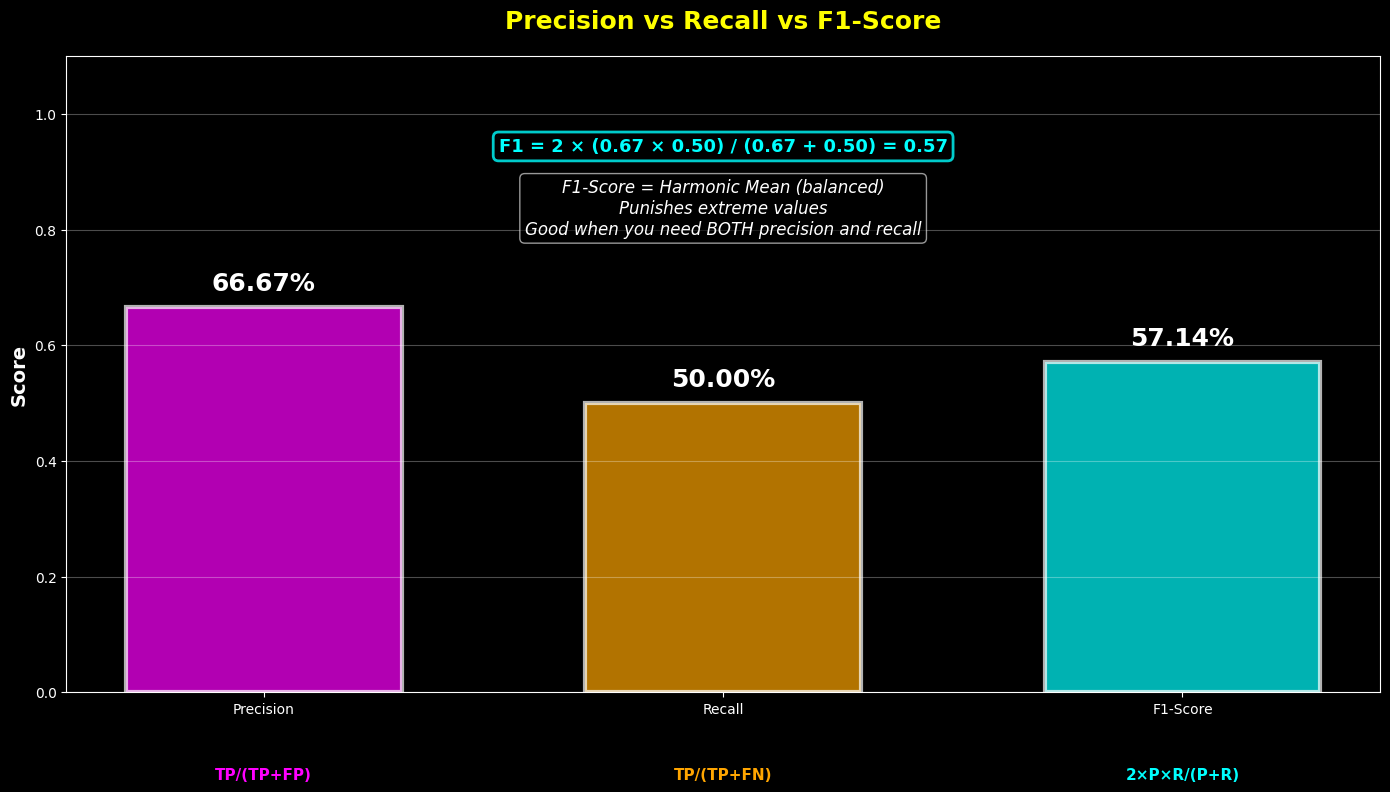


Summary:
Precision = 66.67% - When we predict sick, we're right 67% of time
Recall    = 50.00% - We only catch 50% of sick patients
F1-Score  = 57.14% - Balanced score between both

This model has DECENT precision but POOR recall!
It's conservative - when it says sick, usually right,
but it MISSES half of sick patients (dangerous!)


In [6]:
fig, ax = plt.subplots(figsize=(14, 8))

# Create comparison
metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision, recall, f1]
colors = ['magenta', 'orange', 'cyan']

bars = ax.bar(metrics, values, color=colors, alpha=0.7, 
             edgecolor='white', linewidth=3, width=0.6)

# Add value labels
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
           f'{value:.2%}', ha='center', va='bottom',
           fontsize=18, fontweight='bold', color='white')

# Add formulas
ax.text(0, -0.15, 'TP/(TP+FP)', ha='center', fontsize=11, 
       color='magenta', fontweight='bold')
ax.text(1, -0.15, 'TP/(TP+FN)', ha='center', fontsize=11, 
       color='orange', fontweight='bold')
ax.text(2, -0.15, '2×P×R/(P+R)', ha='center', fontsize=11, 
       color='cyan', fontweight='bold')

# F1 formula breakdown
f1_calc = f"F1 = 2 × ({precision:.2f} × {recall:.2f}) / ({precision:.2f} + {recall:.2f}) = {f1:.2f}"
ax.text(0.5, 0.85, f1_calc, transform=ax.transAxes,
       fontsize=13, fontweight='bold', ha='center', color='cyan',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.8, 
                edgecolor='cyan', linewidth=2))

# Interpretation
interpretation = (
    "F1-Score = Harmonic Mean (balanced)\n"
    "Punishes extreme values\n"
    "Good when you need BOTH precision and recall"
)
ax.text(0.5, 0.72, interpretation, transform=ax.transAxes,
       fontsize=12, ha='center', color='white', style='italic',
       bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))

ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('Precision vs Recall vs F1-Score', 
            fontsize=18, fontweight='bold', pad=20, color='yellow')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSummary:")
print("="*60)
print(f"Precision = {precision:.2%} - When we predict sick, we're right 67% of time")
print(f"Recall    = {recall:.2%} - We only catch 50% of sick patients")
print(f"F1-Score  = {f1:.2%} - Balanced score between both")
print("="*60)
print("\nThis model has DECENT precision but POOR recall!")
print("It's conservative - when it says sick, usually right,")
print("but it MISSES half of sick patients (dangerous!)")

## 6. The Precision-Recall Tradeoff
**You can't maximize both!**

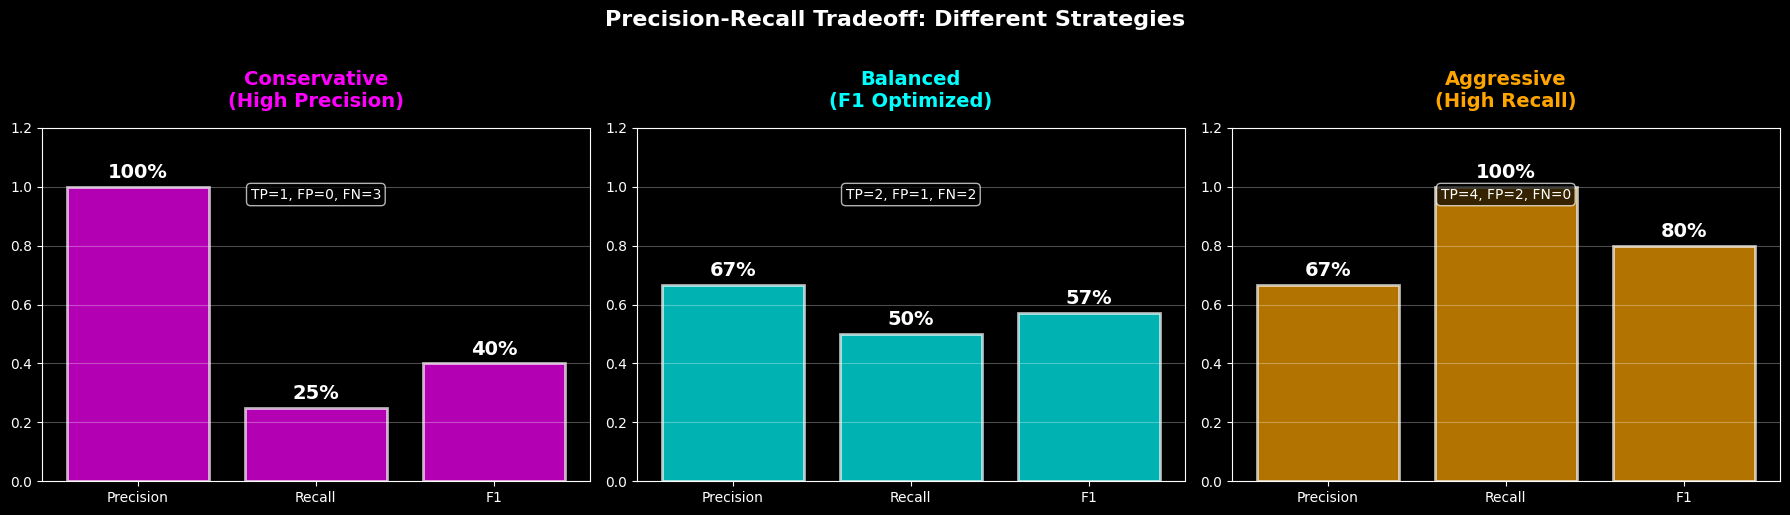


Precision-Recall Tradeoff:
Conservative: High precision (100%), Low recall (25%)
  → Few predictions, but very accurate
  → Use when False Positives are costly

Balanced: Medium precision (67%), Medium recall (50%)
  → Our original model
  → F1-score is highest

Aggressive: Low precision (67%), High recall (100%)
  → Catch all positives, but more false alarms
  → Use when False Negatives are costly


In [7]:
# Simulate different thresholds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scenarios = [
    {'name': 'Conservative\n(High Precision)', 
     'y_pred': np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
     'color': 'magenta'},
    {'name': 'Balanced\n(F1 Optimized)', 
     'y_pred': np.array([1, 1, 0, 0, 1, 0, 0, 0, 0, 0]),
     'color': 'cyan'},
    {'name': 'Aggressive\n(High Recall)', 
     'y_pred': np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0]),
     'color': 'orange'}
]

for ax, scenario in zip(axes, scenarios):
    y_p = scenario['y_pred']
    
    # Calculate metrics
    tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_true, y_p).ravel()
    prec = tp_s / (tp_s + fp_s) if (tp_s + fp_s) > 0 else 0
    rec = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else 0
    f1_s = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    
    # Plot bars
    metrics_vals = [prec, rec, f1_s]
    bars = ax.bar(['Precision', 'Recall', 'F1'], metrics_vals, 
                  color=scenario['color'], alpha=0.7, 
                  edgecolor='white', linewidth=2)
    
    for bar, val in zip(bars, metrics_vals):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.03,
               f'{val:.0%}', ha='center', fontsize=14, 
               fontweight='bold', color='white')
    
    # Confusion matrix summary
    cm_text = f"TP={tp_s}, FP={fp_s}, FN={fn_s}"
    ax.text(0.5, 0.8, cm_text, transform=ax.transAxes,
           fontsize=10, ha='center', color='white',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    
    ax.set_ylim(0, 1.2)
    ax.set_title(scenario['name'], fontsize=14, fontweight='bold', 
                color=scenario['color'], pad=15)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Precision-Recall Tradeoff: Different Strategies', 
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nPrecision-Recall Tradeoff:")
print("="*60)
print("Conservative: High precision (100%), Low recall (25%)")
print("  → Few predictions, but very accurate")
print("  → Use when False Positives are costly\n")

print("Balanced: Medium precision (67%), Medium recall (50%)")
print("  → Our original model")
print("  → F1-score is highest\n")

print("Aggressive: Low precision (67%), High recall (100%)")
print("  → Catch all positives, but more false alarms")
print("  → Use when False Negatives are costly")
print("="*60)

## 7. Key Takeaways

### The Three Metrics:

**Precision = TP / (TP + FP)**
- Of predicted positives, how many are correct?
- "When I say YES, am I right?"
- Focuses on False Positives

**Recall = TP / (TP + FN)**
- Of actual positives, how many did I find?
- "Of all YES cases, how many did I catch?"
- Focuses on False Negatives

**F1-Score = 2 × (Precision × Recall) / (Precision + Recall)**
- Harmonic mean (balanced average)
- Single metric for both
- Punishes extreme imbalance

### When to Use:

**Maximize Precision when:**
- False Positives are costly
- Examples:
  - Spam filter (don't block important emails)
  - Product recommendation (don't annoy with bad suggestions)

**Maximize Recall when:**
- False Negatives are costly
- Examples:
  - Disease detection (don't miss sick patients!)
  - Fraud detection (catch all fraud attempts)
  - Security threats (better safe than sorry)

**Use F1-Score when:**
- Need balance between both
- Both FP and FN are important
- Comparing models with different P-R tradeoffs

### The Tradeoff:
- **High Precision** → Low Recall (conservative)
- **High Recall** → Low Precision (aggressive)
- **Can't maximize both!**
- Choose based on business cost

### Our Tiny Example:
- Precision = 67% (2 of 3 predicted sick are actually sick)
- Recall = 50% (found only 2 of 4 sick patients)
- F1 = 57% (balanced score)
- **Problem: MISSED 2 sick patients! (FN = 2)**

### Remember:
**Different denominators!**
- Precision: Predicted positive denominator
- Recall: Actual positive denominator

**Context is everything!** 🎯